In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import PyMieScatt as ps

# Reproducibility — same "random" numbers every run
np.random.seed(42)
torch.manual_seed(42)

theta shape: (181,)
SU shape: (181,)
First few SU values: [274.50568018 273.77890685 271.60879971 268.02578541 263.07987412]


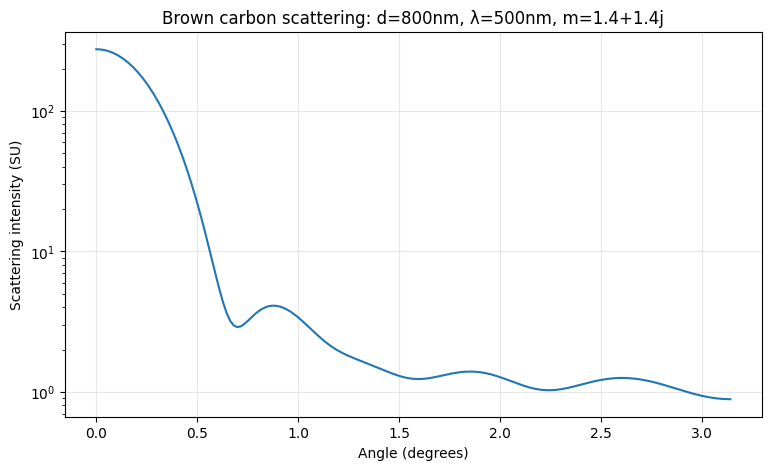

In [5]:
# Brown carbon at the center of our range
n = 1.6
k = 1.0
wavelength = 500   # nm
diameter = 800     # nm

m = complex(n, k)
theta, SL, SR, SU = ps.ScatteringFunction(
    m, wavelength, diameter,
    minAngle=0, maxAngle=180, angularResolution=1
)

print("theta shape:", theta.shape)
print("SU shape:", SU.shape)
print("First few SU values:", SU[:5])

plt.figure(figsize=(9, 5))
plt.plot(theta, SU)
plt.xlabel("Angle (degrees)")
plt.ylabel("Scattering intensity (SU)")
plt.title(f"Brown carbon scattering: d={diameter}nm, λ={wavelength}nm, m=1.4+1.4j")
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
N_SAMPLES = 1000

# Pre-allocate arrays
inputs = np.zeros((N_SAMPLES, 2))     # 2 features: wavelength, diameter
outputs = np.zeros((N_SAMPLES, 181))  # 181 angles per curve

# Fixed values for brown carbon
n = 1.6
k = 1.0
m = complex(n, k)

print("Generating training data through physics")

for i in range(N_SAMPLES):
    # Sample random wavelength and diameter
    wavelength = np.random.uniform(450, 550)
    diameter = np.random.uniform(700, 900)
    
    # Run Mie calculation
    theta, SL, SR, SU = ps.ScatteringFunction(
        m, wavelength, diameter,
        minAngle=0, maxAngle=180, angularResolution=1
    )
    
    # Store inputs and outputs
    inputs[i] = [wavelength, diameter]
    outputs[i] = SU
    
    if i % 100 == 0:
        print(f"  {i}/{N_SAMPLES} done")

print("\nDone!")
print("Inputs shape:", inputs.shape)
print("Outputs shape:", outputs.shape)

Generating training data... (~30 seconds)
  0/1000 done
  100/1000 done
  200/1000 done
  300/1000 done
  400/1000 done
  500/1000 done
  600/1000 done
  700/1000 done
  800/1000 done
  900/1000 done

Done!
Inputs shape: (1000, 2)
Outputs shape: (1000, 181)


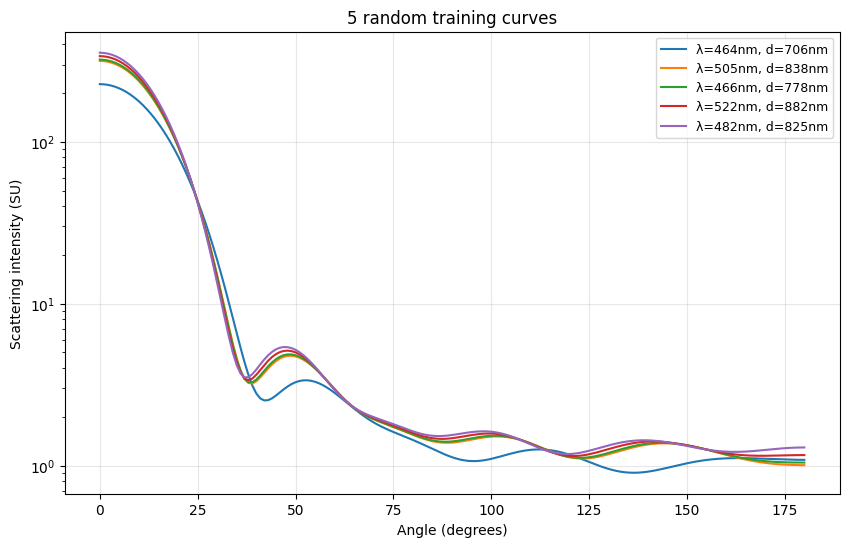

In [ ]:
plt.figure(figsize=(10, 6))

# Plot 5 random curves
indices = np.random.choice(N_SAMPLES, 5, replace=False)

# generate lables for each line
for i in indices:
    label = f"λ={inputs[i,0]:.0f}nm, d={inputs[i,1]:.0f}nm"
    plt.plot(outputs[i], label=label)

plt.xlabel("Angle (degrees)")
plt.ylabel("Scattering intensity (SU)")
plt.title("5 random training curves")
plt.yscale('log')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.show()

graphed 5 random training data points, just to see the shape of the results

In [10]:
# 1. Log-transform the outputs
log_outputs = np.log10(outputs)   # base-10 log

# 2. Normalize the inputs to roughly [0, 1]
# wavelength: 450-550 → (wavelength - 450) / 100
# diameter:   700-900 → (diameter - 700) / 200
inputs_norm = np.zeros_like(inputs)
inputs_norm[:, 0] = (inputs[:, 0] - 450) / 100   # wavelength
inputs_norm[:, 1] = (inputs[:, 1] - 700) / 200   # diameter

# 3. Train/test split — first 800 train, last 200 test
X_train = inputs_norm[:800]
y_train = log_outputs[:800]
X_test = inputs_norm[800:]
y_test = log_outputs[800:]

# Convert to PyTorch tensors
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print()
print("Sample input (normalized):", X_train[0])

X_train shape: torch.Size([800, 2])
y_train shape: torch.Size([800, 181])
X_test shape: torch.Size([200, 2])
y_test shape: torch.Size([200, 181])

Sample input (normalized): tensor([0.3745, 0.9507])


Split the data into training and testing data, formatting the data so it's ready for training. Converting numpy arrays into Tensors.

In [11]:
model = nn.Sequential(
    nn.Linear(2, 64),       # input layer: 2 features → 64 neurons
    nn.ReLU(),
    nn.Linear(64, 128),     # hidden layer: 64 → 128
    nn.ReLU(),
    nn.Linear(128, 181)     # output layer: 128 → 181 (one per angle)
)

print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params}")

Sequential(
  (0): Linear(in_features=2, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=181, bias=True)
)

Total parameters: 31861


building NN layers, applying ReLu between each. Printing the model and counting the number of parameters.

In [12]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

print("Optimizer:", optimizer)
print("Loss function:", loss_fn)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Loss function: MSELoss()


In [16]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

print("Optimizer:", optimizer)
print("Loss function:", loss_fn)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Loss function: MSELoss()


In [ ]:
N_EPOCHS = 200
BATCH_SIZE = 32

train_losses = []
test_losses = []

n_train = X_train.shape[0]   # 800
n_batches = n_train // BATCH_SIZE  # 800 // 32 = 25

print(f"Training: {N_EPOCHS} epochs, {n_batches} batches per epoch\n")

for epoch in range(N_EPOCHS):
    # Shuffle training data each epoch
    perm = torch.randperm(n_train)
    X_shuffled = X_train[perm]
    y_shuffled = y_train[perm]
    
    # Train one epoch (one pass through the data, in mini-batches)
    epoch_loss = 0.0
    for i in range(n_batches):
        start = i * BATCH_SIZE
        end = start + BATCH_SIZE
        X_batch = X_shuffled[start:end]
        y_batch = y_shuffled[start:end]
        
        # Standard 5-step training pattern
        pred = model(X_batch)
        loss = loss_fn(pred, y_batch)
        
        optimizer.zero_grad() # clears gradients from previous batches
        loss.backward() # back propagation to compute gradients for all 31861 weights
        optimizer.step() #updates all weights using the gradients
        
        epoch_loss += loss.item() # accrues the loss over the batches
    
    avg_train_loss = epoch_loss / n_batches # average across all 25 batches
    train_losses.append(avg_train_loss) # save avg loss for plotting
    
    # Evaluate on test set (no gradients needed)
    with torch.no_grad():
        test_pred = model(X_test) #predict on 200 test examples
        test_loss = loss_fn(test_pred, y_test).item() #compute MSE on test set
        test_losses.append(test_loss) # save it
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}  Train Loss: {avg_train_loss:.10f}  Test Loss: {test_loss:.10f}")

print("\nTraining complete!")

Training: 200 epochs, 25 batches per epoch

Epoch   0  Train Loss: 0.0000  Test Loss: 0.0000
Epoch  20  Train Loss: 0.0000  Test Loss: 0.0000
Epoch  40  Train Loss: 0.0000  Test Loss: 0.0000
Epoch  60  Train Loss: 0.0000  Test Loss: 0.0000
Epoch  80  Train Loss: 0.0000  Test Loss: 0.0000
Epoch 100  Train Loss: 0.0000  Test Loss: 0.0000
Epoch 120  Train Loss: 0.0000  Test Loss: 0.0000
Epoch 140  Train Loss: 0.0000  Test Loss: 0.0000
Epoch 160  Train Loss: 0.0000  Test Loss: 0.0000
Epoch 180  Train Loss: 0.0000  Test Loss: 0.0000

Training complete!


In [18]:
print("First 20 epoch losses (real values):")
for i in range(0, 200, 20):
    print(f"Epoch {i:3d}  Train: {train_losses[i]:.2e}  Test: {test_losses[i]:.2e}")

First 20 epoch losses (real values):
Epoch   0  Train: 1.19e-05  Test: 9.78e-06
Epoch  20  Train: 8.91e-06  Test: 8.35e-06
Epoch  40  Train: 8.14e-06  Test: 8.64e-06
Epoch  60  Train: 8.37e-06  Test: 8.30e-06
Epoch  80  Train: 9.53e-06  Test: 8.32e-06
Epoch 100  Train: 7.12e-06  Test: 1.14e-05
Epoch 120  Train: 7.00e-06  Test: 9.66e-06
Epoch 140  Train: 6.11e-06  Test: 5.44e-06
Epoch 160  Train: 7.12e-06  Test: 4.47e-06
Epoch 180  Train: 6.55e-06  Test: 5.11e-06
